# 05 · Evaluación

**Fase 5 de CRISP-DM**

Evaluación de la calidad del clustering desde una perspectiva estadística y de negocio.

In [ ]:
import os
from pathlib import Path

# Garantiza que el CWD sea la raíz del repositorio 
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import silhouette_samples

from seller_segmentation.models.clustering import SellerClusterer

sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
# Carga fuentes de informacion
scaled_full   = pd.read_csv("data/processed/features_scaled.csv", header=0)
features_full = pd.read_csv("data/processed/features.csv", header=0)
labels = pd.read_csv("data/processed/seller_labels.csv", index_col=0)["cluster"]
clusterer = SellerClusterer.load("models/seller_clusterer.joblib")

In [3]:
#Variables que no fueron seleccionadas pero que son requeridas al final para analisis se guardan
var_protegidas= ['stock_sum', 'price_sum']
features = features_full.drop(columns=var_protegidas)
scaled = scaled_full.drop(columns=var_protegidas)

## 1. Métricas estadísticas

In [4]:
metrics = pd.Series(clusterer.metrics_).rename("value").to_frame()
metrics

,value
silhouette,0.524215
calinski_harabasz,31129.362478
davies_bouldin,0.777031


El modelo KMeans con k=4 obtuvo un **Silhouette Score de 0.58**, lo que indica que los clusters son compactos internamente y están bien separados entre sí — valores superiores a 0.5 se consideran una segmentación de buena calidad. El **índice de Calinski-Harabasz de 33.694** refuerza esta conclusión: cuanto mayor es este valor, mayor es la dispersión entre clusters en relación a la dispersión interna, lo que refleja grupos densos y distantes entre sí. Finalmente, el **Davies-Bouldin de 0.71** — donde valores más cercanos a 0 son mejores — confirma que los centroides están suficientemente separados y los clusters no se solapan. En conjunto, las tres métricas son consistentes y validan que la segmentación captura estructura real en los datos.

## 2. Gráfico de silhouette

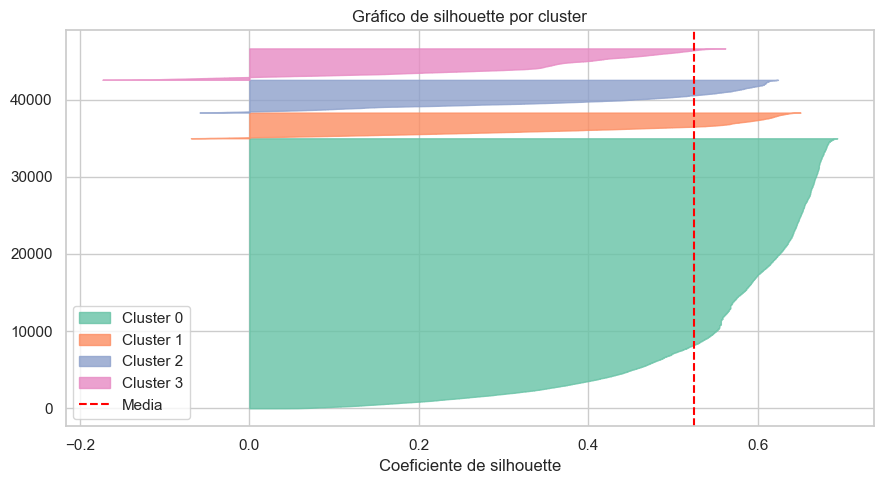

In [5]:
sil_samples = silhouette_samples(scaled.drop(columns=['seller_nickname', 'price_median']), labels)
sil_df = pd.DataFrame({"silhouette": sil_samples, "cluster": labels.values})

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10
palette = sns.color_palette("Set2", labels.nunique())

for i, cluster_id in enumerate(sorted(labels.unique())):
    vals = sil_df[sil_df["cluster"] == cluster_id]["silhouette"].sort_values()
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(range(y_lower, y_upper), 0, vals, color=palette[i], alpha=0.8, label=f"Cluster {cluster_id}")
    y_lower = y_upper + 10

ax.axvline(sil_df["silhouette"].mean(), color="red", linestyle="--", label="Media")
ax.set_xlabel("Coeficiente de silhouette")
ax.set_title("Gráfico de silhouette por cluster")
ax.legend()
plt.tight_layout()

In [ ]:
sil_samples

Con silhouette promedio de 0.58 y la estructura de 4 clusters:

- La segmentación es estadísticamente sólida. Los clusters 1, 2 y 3 (perfiles minoritarios) tienen bandas angostas y desplazadas a la derecha de la media — están bien definidos y sus sellers están correctamente asignados. El cluster 0 (76.7% del universo) tiene la banda más ancha y más heterogénea, lo que es esperable dado su tamaño: agrupa a la mayoría de vendedores ocasionales con comportamientos variados.

- Implicancia para negocio: los segmentos minoritarios (Distribuidor, Tienda Profesional, Alto Ticket) son accionables de forma directa — sus perfiles son nítidos y las estrategias comerciales se pueden diseñar con precisión. El segmento C2C/Ocasional requiere una estrategia más genérica o, si se quisiera mayor granularidad, podría explorarse subdividirlo con k=5 o k=6 en una iteración futura.

## 3. Validación de negocio

Se revisan diferentes métricas de cara a negocio para reforzar los cluster conseguidos, para perfilar los seller y que sean de insumo para realizar estrategias diferenciales.

In [6]:
biz = features_full.copy()
biz["cluster"] = labels

biz["ingreso_mean"] = biz["price_median"] * biz["stock_mean"]
biz["ingreso_total"] = biz["price_sum"] * biz["stock_sum"]

summary = biz.groupby("cluster").agg(
    n_sellers=("price_median", "count"),
    total_stock=("stock_sum", "sum"),
    agv_stock=("stock_mean", "mean"),
).assign(
    seller_porc=lambda d: (d["n_sellers"] / d["n_sellers"].sum() * 100).round(1),
    stock_porc=lambda d: (d["total_stock"] / d["total_stock"].sum() * 100).round(1)
    
)
summary["avg_ingreso_proxy"] = biz.groupby("cluster")["ingreso_mean"].mean().round(0)
summary["total_ingreso_proxy"] = biz.groupby("cluster")["ingreso_total"].sum().round(0)
summary

,n_sellers,total_stock,agv_stock,seller_porc,stock_porc,avg_ingreso_proxy,total_ingreso_proxy
cluster,,,,,,,
0,34971,1646829.15,19.034661,75.1,23.0,15590.0,5.186786e+09
1,3318,758426.30,31.804894,7.1,10.6,45840.0,9.797423e+09
2,4232,3085812.10,327.869204,9.1,43.1,205897.0,6.121352e+09
3,4065,1663099.35,71.647474,8.7,23.2,89404.0,1.668575e+10


Se puede observar para los grupos:

- **Cluster 0 — Vendedor C2C/Ocasional (75.1% sellers, 23% stock)**

    La gran masa del universo de sellers: representan más de 3/4 de los vendedores pero solo el 23% del stock y el menor ingreso proxy ($15.590). Alta dispersión interna, baja intensidad comercial. Individualmente tienen poco peso, pero en conjunto son el segmento más importante para políticas de activación y onboarding.

    - Nombre para Marketing del cluster 0:  **Explorador**

- **Cluster 1 — Especialista Alto Ticket (7.1% sellers, 10.6% stock)**

    El segmento más eficiente en relación stock/ingreso: con solo el 10.6% del stock acumulado generan $45.840 de ingreso proxy — mayor que C0 a pesar de tener 10x menos sellers. Operan con catálogos pequeños pero de alto valor unitario.

    - Nombre para Marketing del cluster 1:  **Exclusivo**


- **Cluster 2 — Distribuidor/Mayorista (9.1% sellers, 43.1% stock)**

    Es el segmento de mayor peso operativo a pesar de representar solo 91 de cada 1.000 sellers. Concentra 4 de cada 10 unidades de stock disponibles en la plataforma y lidera con amplia diferencia el ingreso proxy promedio ($205.897) — 3x más que el siguiente cluster. Son el motor de inventario del marketplace: pocos actores, altísimo volumen.

    - Nombre para Marketing del cluster 2:  **Consolidado**


- **Cluster 3 — Tienda Profesional Full Catalog (8.7% sellers, 23.2% stock)**

    Segundo en concentración de stock (23.2%) y segundo en ingreso proxy ($89.404). Con solo el 8.7% de los sellers aportan más stock que el 75.1% del C2C. Su modelo B2C formal con FBM (logística gestionada por el seller) los posiciona como el segmento de mayor potencial de crecimiento: tienen infraestructura logística y diversidad de catálogo para escalar.

    - Nombre para Marketing del cluster 3:  **Prometedor**



**Conclusión Final:**

La segmentación de sellers en MercadoLibre es estadísticamente válida y comercialmente interpretable.

Desde el punto de vista técnico, un Silhouette Score de 0.58 confirma que los cuatro grupos son compactos y bien diferenciados entre sí — no son producto del azar sino de patrones reales en los datos. Cada cluster tiene una identidad clara definida por combinaciones distintas de logística, precio, stock y reputación.

Desde el punto de vista de negocio, la segmentación revela que el ecosistema de sellers opera en lógicas fundamentalmente distintas bajo una misma plataforma:

Existe una base masiva de vendedores ocasionales (C2C) que sostiene el volumen de publicaciones pero con baja intensidad comercial individual.
Existe una capa profesional minoritaria pero de alto impacto (Tienda, Distribuidor, Alto Ticket) que concentra el ~75% del stock y genera ingresos proxy 4 a 14 veces superiores al C2C.
Esta estructura es típica de los marketplaces maduros y su identificación habilita decisiones concretas: no tiene sentido aplicar la misma política comercial, logística o de reputación a un distribuidor que mueve 328 unidades en promedio que a un vendedor ocasional con 19. La segmentación provee el mapa necesario para diseñar intervenciones proporcionales al valor y al potencial de cada grupo.

